In [1]:
import os
from CSTREnv import CSTREnv
from stable_baselines3 import DDPG, SAC, PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.results_plotter import load_results
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.pyplot as plt
import numpy as np
import random
import time
import pandas as pd
from matplotlib.ticker import ScalarFormatter

In [2]:
def generate_initial_points():
    fir = np.linspace(-2, 2, 40)
    sec = np.linspace(-100.0, 100.0, 200)
    pts = []

    for i in fir:
        for j in sec:
            x = np.array([i, j])
            P = np.array([[1060, 22],[22, 0.52]])
            if x @ P @ x < 372:
                pts.append(x)

    random.shuffle(pts)
    return pts

initial_points = generate_initial_points()

In [19]:
def test(obs0, env, agent, n_steps=100):

    obs = obs0.copy()

    CA_traj = [obs[0]]
    T_traj  = [obs[1]]
    U_traj  = []          # store actions
    time    = [0.0]

    for k in range(1, n_steps + 1):
        action, _ = agent.predict(obs, deterministic=True)
        U_traj.append(action.copy()) 

        obs, reward, terminated, truncated, _ = env.step(action)

        CA_traj.append(obs[0])
        T_traj.append(obs[1])
        time.append(k * 1e-2)

    action, _ = agent.predict(obs, deterministic=True)
    U_traj.append(action.copy())
    return (
        np.array(time),
        np.array(CA_traj),
        np.array(T_traj),
        np.array(U_traj),
    )

In [8]:
# Load trained model
ppo_agent = PPO.load("ppo_cstr") 
ddpg_agent = DDPG.load("ddpg_cstr")
sac_agent = SAC.load("sac_cstr")

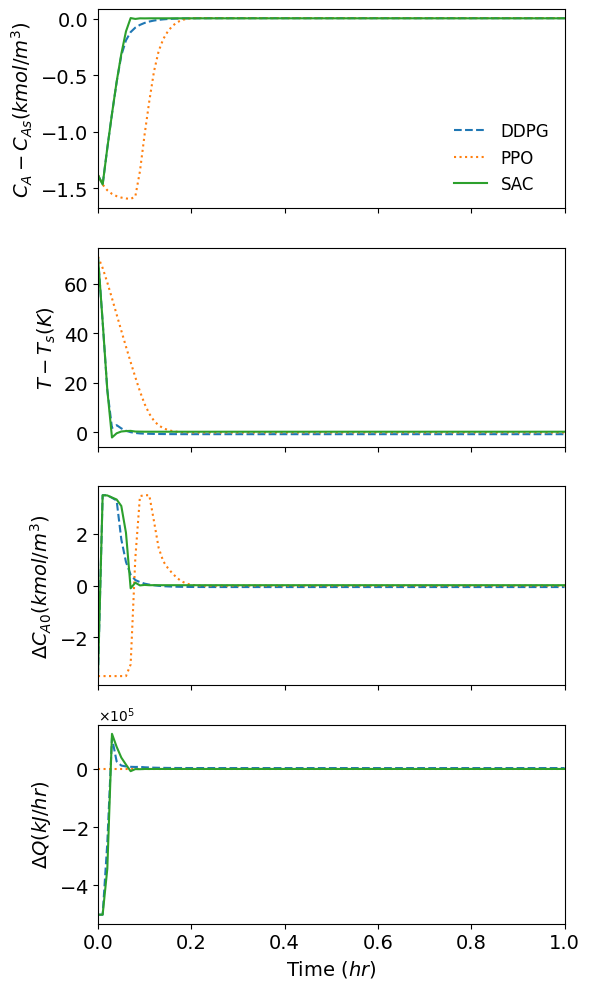

In [25]:
agents = {
    "DDPG": ddpg_agent,
    "PPO": ppo_agent,
    "SAC": sac_agent
}

linestyles = {
    "DDPG": "--",
    "PPO": ":",
    "SAC": "-"
}

x0 = np.array([-1.38461538, 70.85427136])
#x0 = np.array([0.3, -30])
title = "IC 2"
colors = {"DDPG": "C0", "PPO": "C1", "SAC": "C2"}
fontsize = 14

# 4 rows × 1 column
fig, axs = plt.subplots(4, 1, figsize=(6, 10), sharex=True)

trajectories = {alg: [] for alg in agents}
controls = {alg: [] for alg in agents}

for alg_name, agent in agents.items():
    env = Monitor(CSTREnv(is_train=False))
    obs, _ = env.reset(state=x0)
    t, CA, T, U = test(x0, env, agent)

    trajectories[alg_name].append((t, CA, T))
    controls[alg_name].append((t, U))

# -------- Plot C_A --------
for alg_name, traj_list in trajectories.items():
    for t, CA, T in traj_list:
        axs[0].plot(t, CA, color=colors[alg_name], linestyle=linestyles[alg_name], label=alg_name, linewidth=1.5)
axs[0].set_xlim(0, 1)
axs[0].tick_params(axis="both", labelsize=fontsize)
axs[0].set_ylabel(r"$C_A - C_{As} (kmol/m^3)$", fontsize=fontsize)

# -------- Plot T --------
for alg_name, traj_list in trajectories.items():
    for t, CA, T in traj_list:
        axs[1].plot(t, T, color=colors[alg_name], linestyle=linestyles[alg_name], linewidth=1.5)
axs[1].set_xlim(0, 1)
axs[1].tick_params(axis="both", labelsize=fontsize)
axs[1].set_ylabel(r"$T - T_s (K)$", fontsize=fontsize)

# -------- Plot u1 (delta CA0) --------
for alg_name, ctrl_list in controls.items():
    for t, U in ctrl_list:
        axs[2].plot(t, U[:, 0], color=colors[alg_name], linestyle=linestyles[alg_name], linewidth=1.5, label=alg_name)
axs[2].set_xlim(0, 1)
axs[2].tick_params(axis="both", labelsize=fontsize)
axs[2].set_ylabel(r"$\Delta C_{A0} (kmol/m^3)$", fontsize=fontsize)

# -------- Plot u2 (delta Q) --------
for alg_name, ctrl_list in controls.items():
    for t, U in ctrl_list:
        axs[3].plot(t, U[:, 1], color=colors[alg_name], linestyle=linestyles[alg_name], linewidth=1.5, label=alg_name)
axs[3].set_xlim(0, 1)
axs[3].set_xlabel("Time $(hr)$", fontsize=fontsize)
axs[3].tick_params(axis="both", labelsize=fontsize)
axs[3].set_ylabel(r"$\Delta Q (kJ/hr)$", fontsize=fontsize)

# Scientific notation for u2
axs[3].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
axs[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

# Legend only once (top subplot)
axs[0].legend(fontsize=fontsize-2, frameon=False)

plt.tight_layout()
plt.savefig("trajectories_and_controls.eps", format="eps", bbox_inches="tight")
plt.show()